<a href="https://colab.research.google.com/github/mandasneha2006-blip/EEG-processing1/blob/main/EEG_signal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
# BLOCK 1: INSTALL REQUIRED LIBRARIES
# ============================================================

# MNE is used for EEG/MEG data processing
# Matplotlib is used to create EEG images
# NumPy is used for numerical operations
# SciPy is used for signal processing

!pip install -q mne

In [ ]:
# ============================================================
# BLOCK 2: IMPORT LIBRARIES
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import mne
import os

from scipy.signal import butter, filtfilt, iirnotch

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
# ============================================================
# BLOCK 3: DOWNLOAD A SMALL EEG RECORDING
# ============================================================

# Create a folder for our EEG data
os.makedirs("/content/eeg_data", exist_ok=True)

# Direct PhysioNet URL
url = "https://physionet.org/files/eegmmidb/1.0.0/S001/S001R03.edf"

# Download the EEG file
!wget -q -O /content/eeg_data/S001R03.edf $url

print("EEG file downloaded successfully!")
print("File:", "/content/eeg_data/S001R03.edf")

EEG file downloaded successfully!
File: /content/eeg_data/S001R03.edf


In [ ]:
# ============================================================
# BLOCK 4: READ EEG DATA
# ============================================================

file_path = "/content/eeg_data/S001R03.edf"

# Read the EDF EEG file
raw = mne.io.read_raw_edf(
    file_path,
    preload=True,
    verbose=False
)

# Print basic information
print(raw)
print("\nSampling frequency:", raw.info["sfreq"], "Hz")
print("Number of channels:", len(raw.ch_names))

# Show channel names
print("\nFirst 10 EEG channels:")
print(raw.ch_names[:10])

<RawEDF | S001R03.edf, 64 x 20000 (125.0 s), ~9.8 MiB, data loaded>

Sampling frequency: 160.0 Hz
Number of channels: 64

First 10 EEG channels:
['Fc5.', 'Fc3.', 'Fc1.', 'Fcz.', 'Fc2.', 'Fc4.', 'Fc6.', 'C5..', 'C3..', 'C1..']


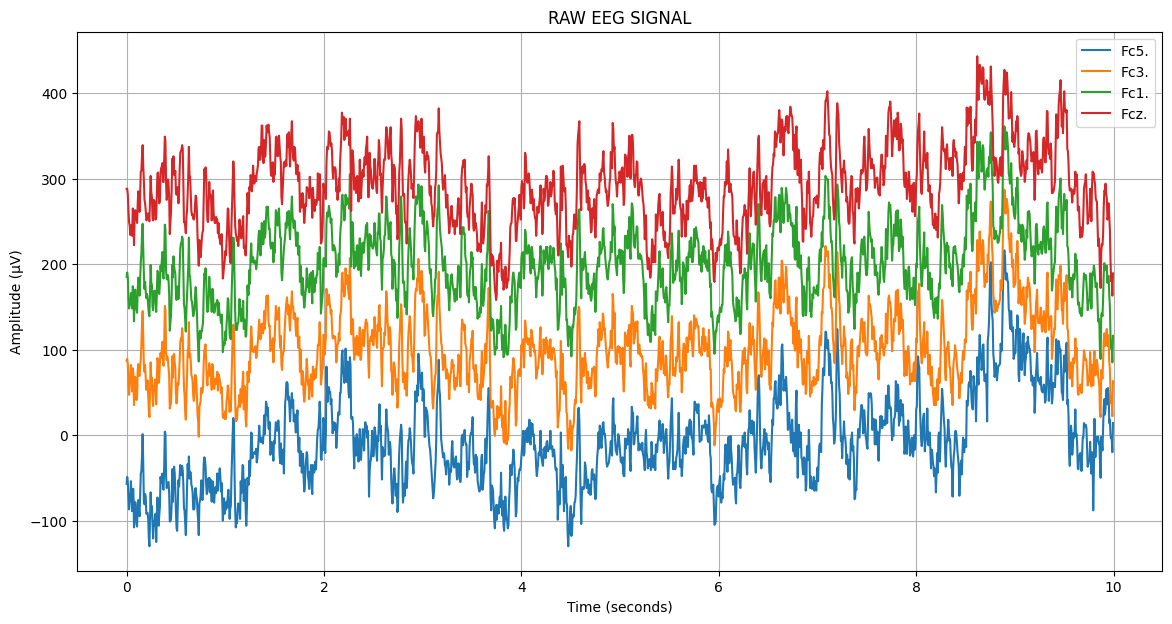

In [ ]:
# ============================================================
# BLOCK 5: CONVERT RAW EEG INTO IMAGE
# ============================================================

# Select first 4 EEG channels
channels_to_use = raw.ch_names[:4]

# Get EEG data
data = raw.get_data(
    picks=channels_to_use
)

# Sampling frequency
fs = raw.info["sfreq"]

# Take first 10 seconds
duration = 10
samples = int(duration * fs)

data = data[:, :samples]

# Create time axis
time = np.arange(samples) / fs

# Create EEG image
plt.figure(figsize=(14, 7))

for i in range(len(channels_to_use)):

    # Offset each channel so they don't overlap
    signal = data[i] * 1e6
    offset = i * 100

    plt.plot(
        time,
        signal + offset,
        label=channels_to_use[i]
    )

plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude (µV)")
plt.title("RAW EEG SIGNAL")
plt.legend()
plt.grid(True)

plt.show()

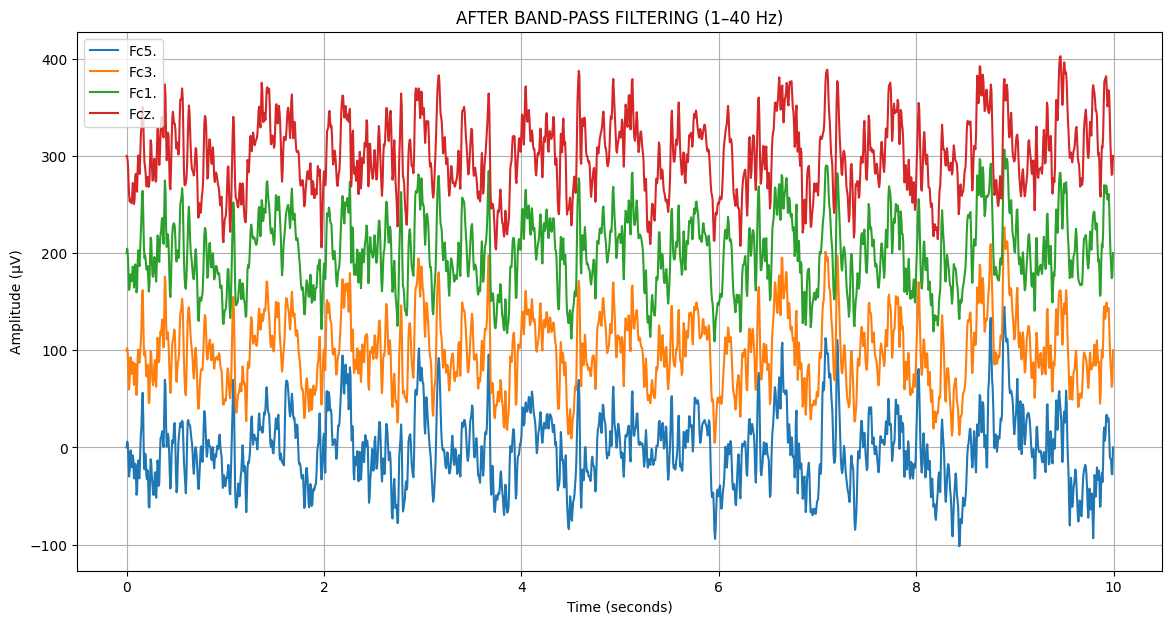

In [ ]:

# ============================================================
# BLOCK 6: BAND-PASS FILTERING
# ============================================================

# Define band-pass limits
low_cutoff = 1
high_cutoff = 40

# Apply MNE band-pass filter
bandpass_data = mne.filter.filter_data(
    data,
    sfreq=fs,
    l_freq=low_cutoff,
    h_freq=high_cutoff,
    verbose=False
)

# Plot filtered EEG
plt.figure(figsize=(14, 7))

for i in range(len(channels_to_use)):

    signal = bandpass_data[i] * 1e6
    offset = i * 100

    plt.plot(
        time,
        signal + offset,
        label=channels_to_use[i]
    )

plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude (µV)")
plt.title("AFTER BAND-PASS FILTERING (1–40 Hz)")
plt.legend()
plt.grid(True)

plt.show()

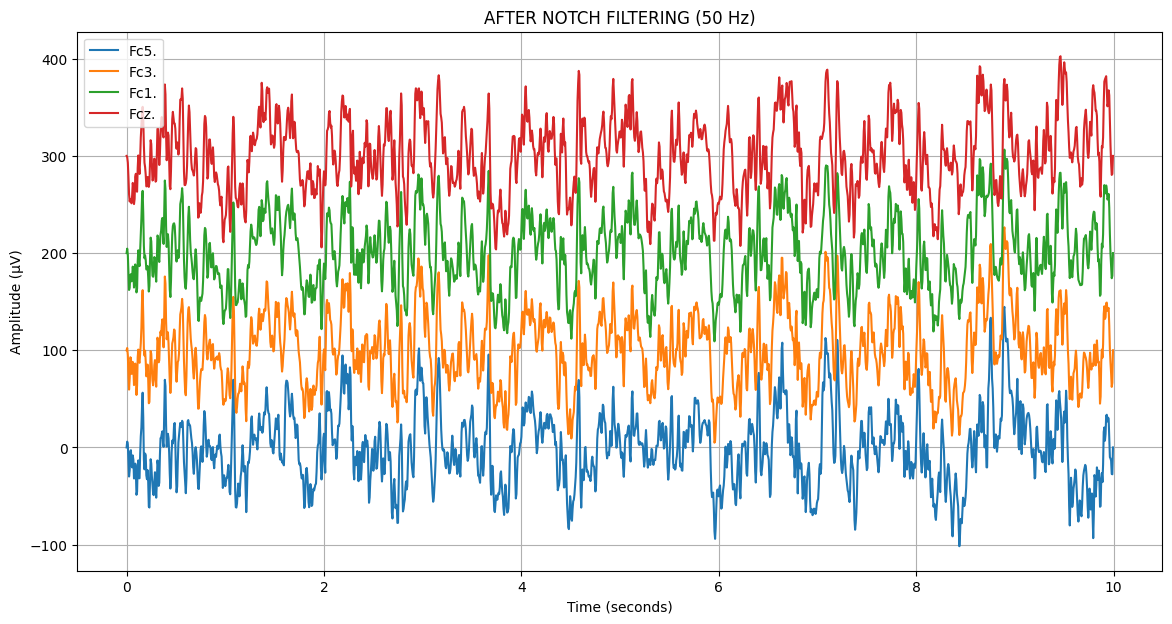

In [ ]:
# ============================================================
# BLOCK 7: NOTCH FILTERING
# ============================================================

# Remove 50 Hz power-line interference
notch_data = mne.filter.notch_filter(
    bandpass_data,
    Fs=fs,
    freqs=50,
    verbose=False
)

# Plot EEG after notch filtering
plt.figure(figsize=(14, 7))

for i in range(len(channels_to_use)):

    signal = notch_data[i] * 1e6
    offset = i * 100

    plt.plot(
        time,
        signal + offset,
        label=channels_to_use[i]
    )

plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude (µV)")
plt.title("AFTER NOTCH FILTERING (50 Hz)")
plt.legend()
plt.grid(True)

plt.show()

Number of detected artifact samples: 31


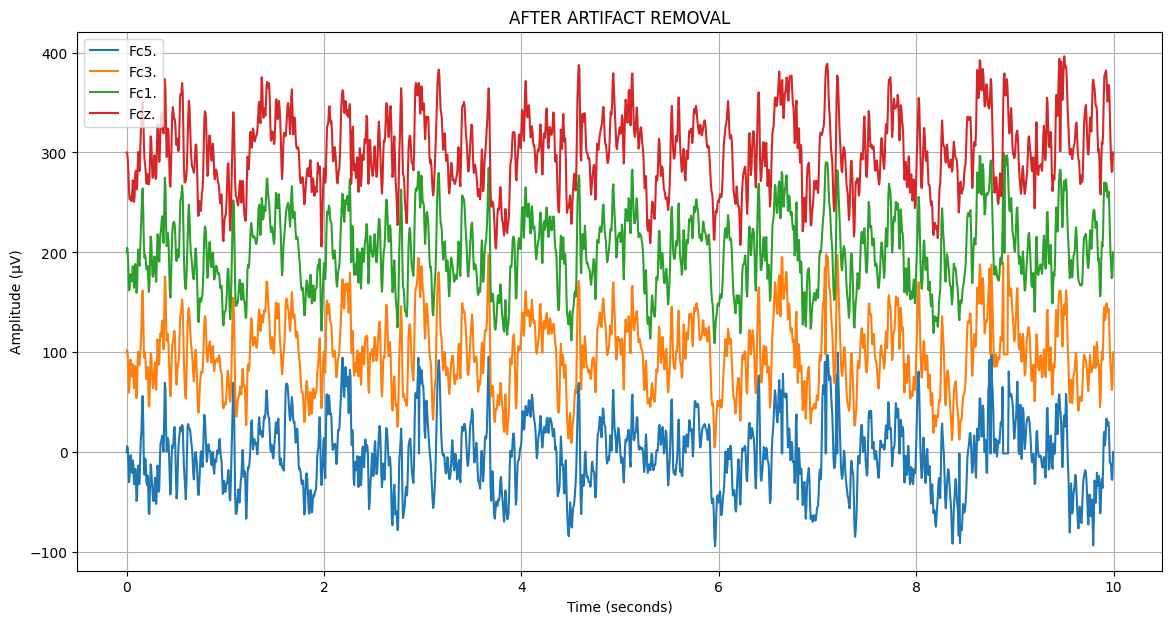

In [ ]:
# ============================================================
# BLOCK 8: SIMPLE ARTIFACT REMOVAL
# ============================================================

# Convert EEG to microvolts
artifact_data = notch_data * 1e6

# Define an amplitude threshold
threshold = 100

# Detect very large values
artifact_mask = np.abs(artifact_data) > threshold

# Count artifacts
number_of_artifacts = np.sum(artifact_mask)

print("Number of detected artifact samples:",
      number_of_artifacts)

# Replace extreme values with the channel median
for i in range(artifact_data.shape[0]):

    median_value = np.median(artifact_data[i])

    artifact_data[i][artifact_mask[i]] = median_value

# Convert back to volts
artifact_data = artifact_data / 1e6

# Plot
plt.figure(figsize=(14, 7))

for i in range(len(channels_to_use)):

    signal = artifact_data[i] * 1e6
    offset = i * 100

    plt.plot(
        time,
        signal + offset,
        label=channels_to_use[i]
    )

plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude (µV)")
plt.title("AFTER ARTIFACT REMOVAL")
plt.legend()
plt.grid(True)

plt.show()

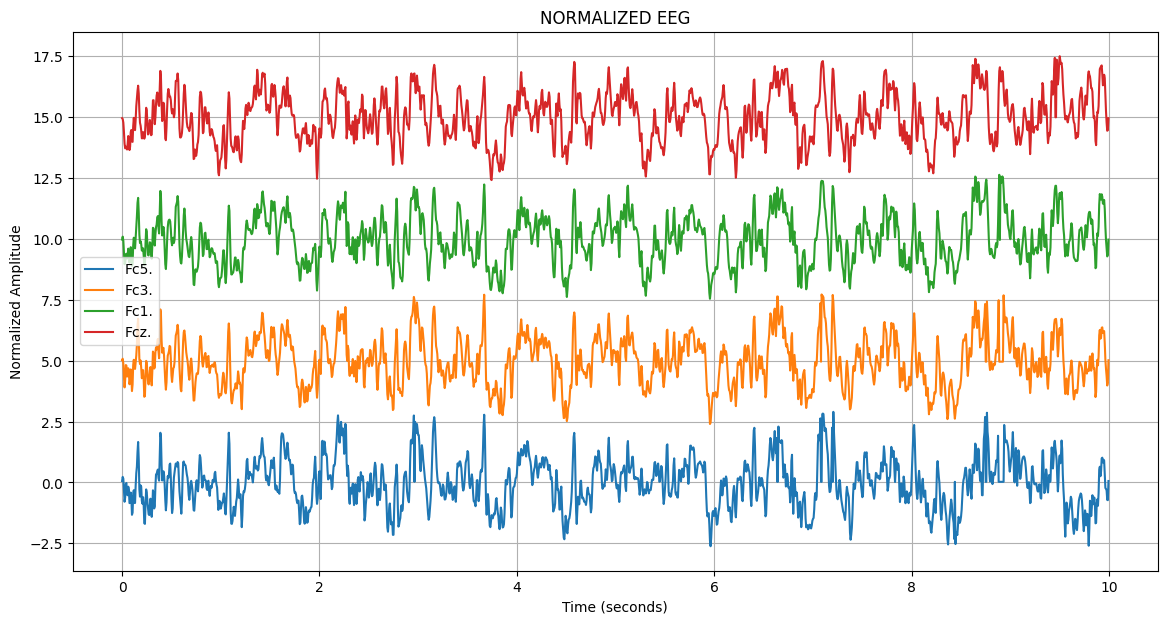

In [ ]:
# ============================================================
# BLOCK 9: NORMALIZATION
# ============================================================

# Copy the artifact-free signal
normalized_data = artifact_data.copy()

# Normalize each channel independently
for i in range(normalized_data.shape[0]):

    mean = np.mean(normalized_data[i])
    std = np.std(normalized_data[i])

    normalized_data[i] = (
        normalized_data[i] - mean
    ) / (std + 1e-8)

# Plot normalized EEG
plt.figure(figsize=(14, 7))

for i in range(len(channels_to_use)):

    signal = normalized_data[i]
    offset = i * 5

    plt.plot(
        time,
        signal + offset,
        label=channels_to_use[i]
    )

plt.xlabel("Time (seconds)")
plt.ylabel("Normalized Amplitude")
plt.title("NORMALIZED EEG")
plt.legend()
plt.grid(True)

plt.show()

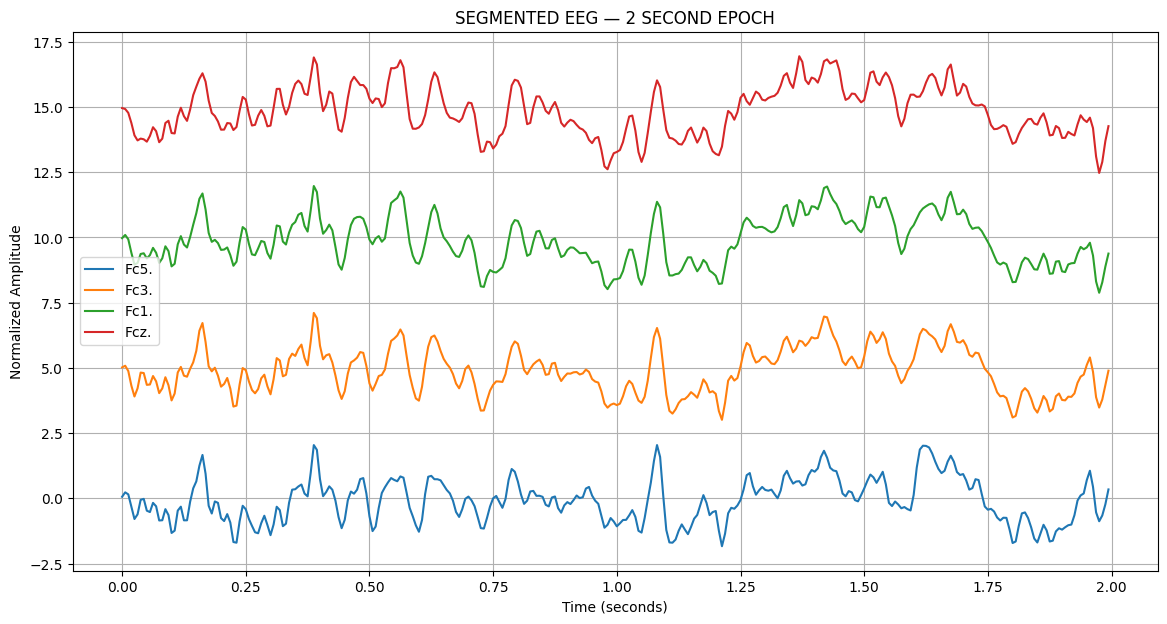

In [ ]:
# ============================================================
# BLOCK 10: EEG SEGMENTATION
# ============================================================

segment_duration = 2

segment_samples = int(
    segment_duration * fs
)

# Take first segment
segment = normalized_data[:, :segment_samples]

segment_time = np.arange(
    segment_samples
) / fs

# Display segment
plt.figure(figsize=(14, 7))

for i in range(len(channels_to_use)):

    signal = segment[i]
    offset = i * 5

    plt.plot(
        segment_time,
        signal + offset,
        label=channels_to_use[i]
    )

plt.xlabel("Time (seconds)")
plt.ylabel("Normalized Amplitude")
plt.title("SEGMENTED EEG — 2 SECOND EPOCH")
plt.legend()
plt.grid(True)

plt.show()

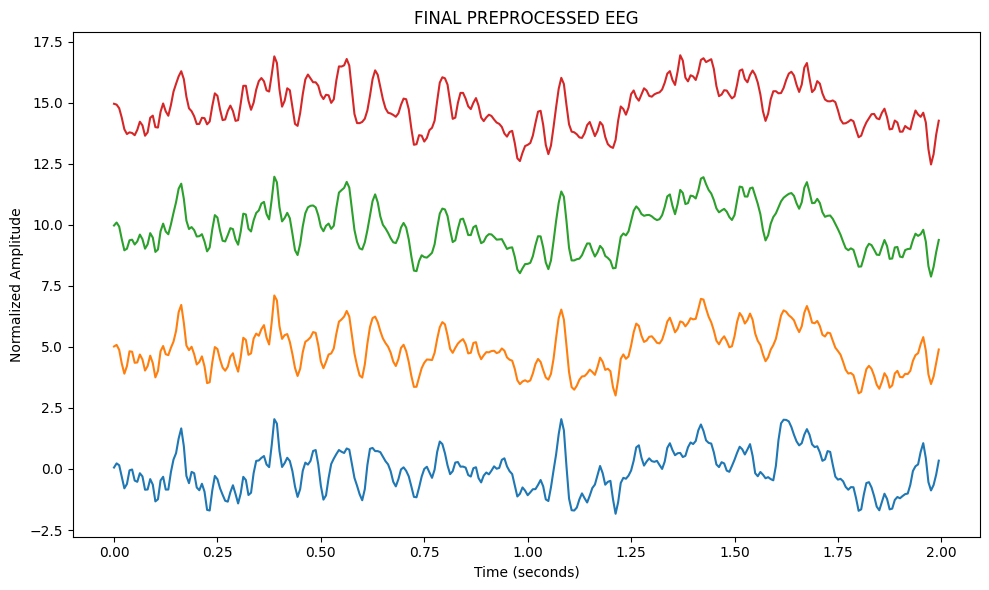

Final EEG image saved at:
/content/preprocessed_eeg.png


In [ ]:
# ============================================================
# BLOCK 11: SAVE FINAL EEG AS IMAGE
# ============================================================

output_path = "/content/preprocessed_eeg.png"

plt.figure(figsize=(10, 6))

for i in range(len(channels_to_use)):

    signal = segment[i]
    offset = i * 5

    plt.plot(
        segment_time,
        signal + offset
    )

plt.xlabel("Time (seconds)")
plt.ylabel("Normalized Amplitude")
plt.title("FINAL PREPROCESSED EEG")

plt.tight_layout()

# Save EEG as image
plt.savefig(
    output_path,
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print("Final EEG image saved at:")
print(output_path)

Image size: (1484, 881)
Image mode: RGBA


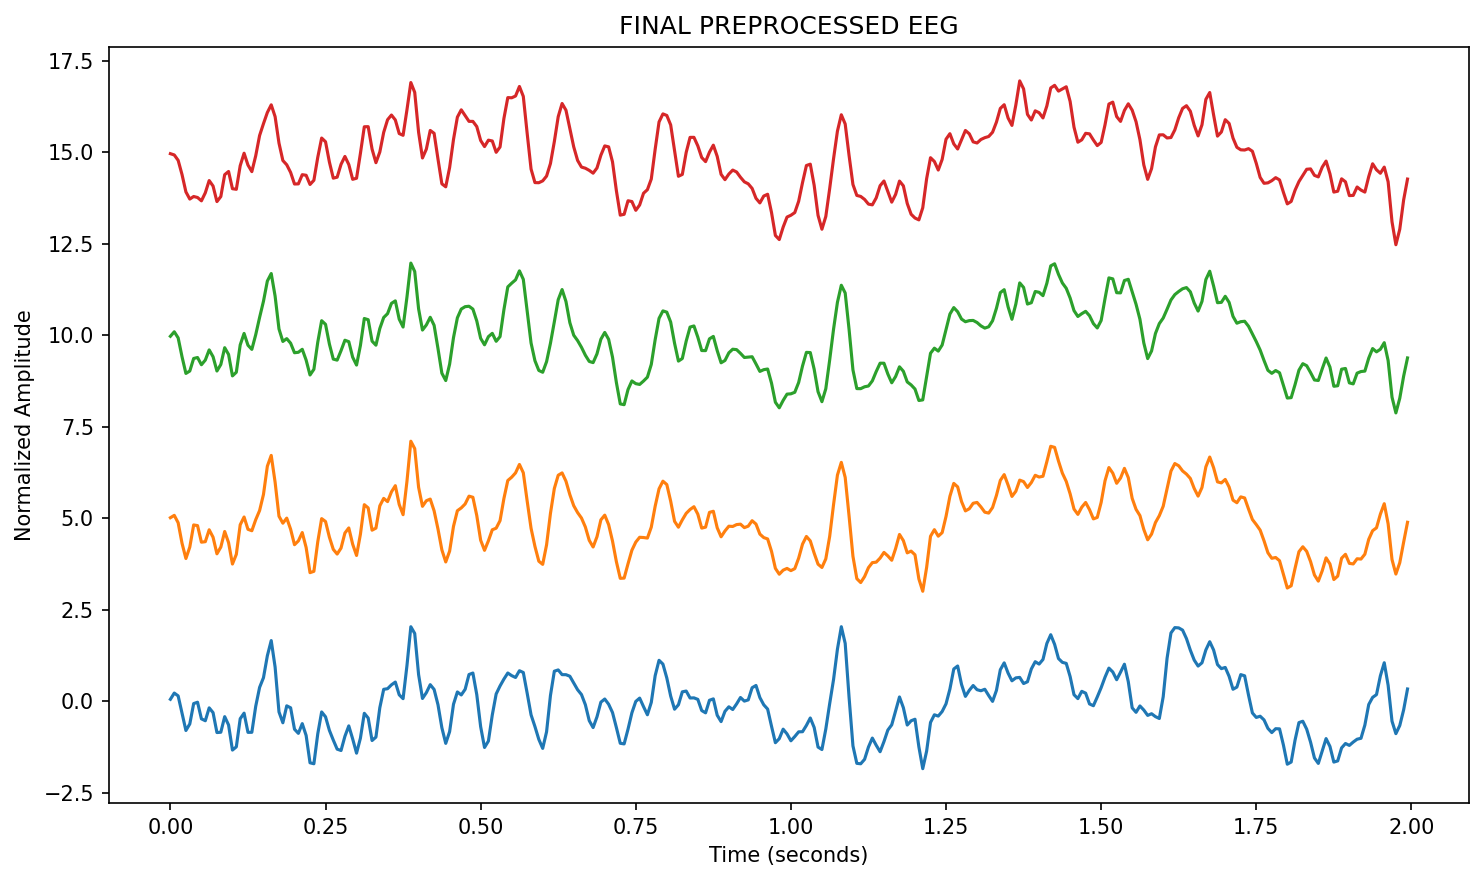

In [ ]:
# ============================================================
# BLOCK 12: LOAD EEG IMAGE AS IMAGE INPUT
# ============================================================

from PIL import Image

# Read the EEG image
eeg_image = Image.open(
    "/content/preprocessed_eeg.png"
)

print("Image size:", eeg_image.size)
print("Image mode:", eeg_image.mode)

# Display the image
display(eeg_image)

Image converted to grayscale.


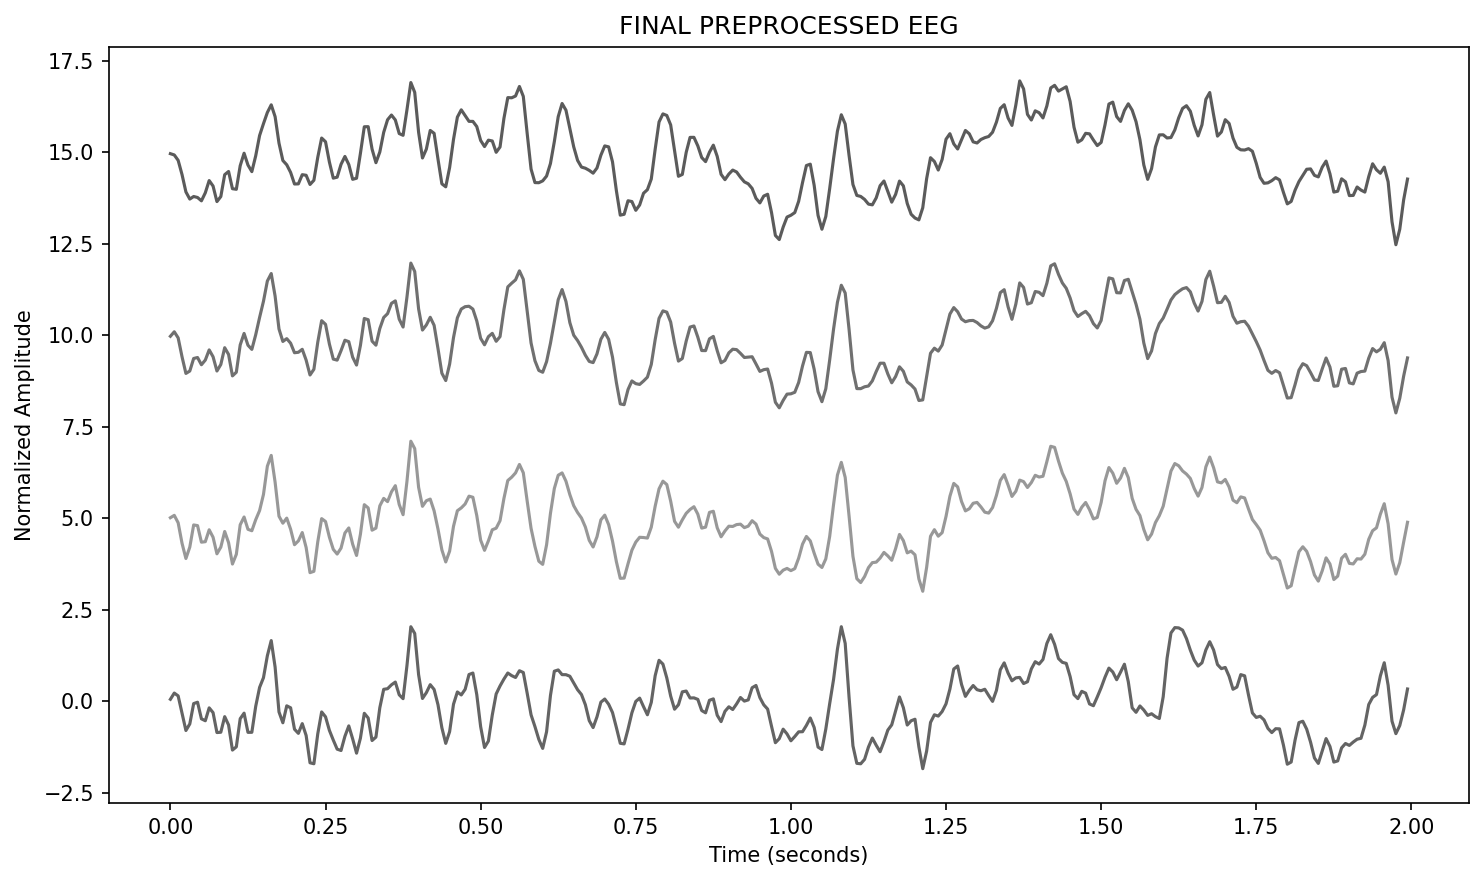

In [ ]:
# ============================================================
# BLOCK 13: CONVERT EEG IMAGE TO GRAYSCALE
# ============================================================

gray_image = eeg_image.convert("L")

print("Image converted to grayscale.")

display(gray_image)

New image size: (224, 224)


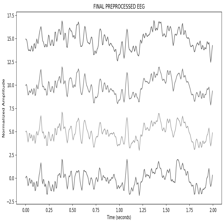

In [ ]:
# ============================================================
# BLOCK 14: RESIZE EEG IMAGE
# ============================================================

image_size = (224, 224)

resized_image = gray_image.resize(
    image_size
)

print("New image size:",
      resized_image.size)

display(resized_image)

Minimum pixel value: 0.39215686274509803
Maximum pixel value: 1.0


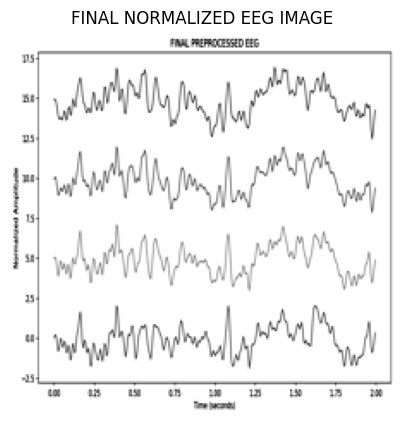

In [ ]:
# ============================================================
# BLOCK 15: IMAGE NORMALIZATION
# ============================================================

# Convert image into NumPy array
image_array = np.array(resized_image)

# Normalize pixels from 0–255 to 0–1
normalized_image = image_array / 255.0

print("Minimum pixel value:",
      normalized_image.min())

print("Maximum pixel value:",
      normalized_image.max())

# Display normalized image
plt.figure(figsize=(5, 5))

plt.imshow(
    normalized_image,
    cmap="gray"
)

plt.title("FINAL NORMALIZED EEG IMAGE")
plt.axis("off")

plt.show()